# Manual Assess Expr1 Fsize Plot

Use this notebook on `af309` after you manually download compute-node data to a local data root such as `~/code/data/<date>/<host>/outputAssessing/`.  The notebook reuses `scripts_plot/assess_plot.py` for parsing and metric calculation, then lets you choose the data root, date, hosts, expressions, batches, and output directory.

In [4]:
from pathlib import Path

# ---- edit these parameters ----
DATA_ROOT = Path.home() / "code/data"
DATE = "20260521"
HOSTS = ["cgnr6760pn2"]
EXPRS = ["assess.expr1.fsize.np64"]
OUTPUT_DIR = Path("scripts_plot/outputAssessing/manual_expr1_fsize")

# If True, scan every timestamped batch. If False, keep latest batch per host+expr.
ALL_BATCHES = True

# Select only full Fig6-style rows.
EXPECTED_SAMPLES = 300  # NWALKS * NTESTS, e.g. 3 * 100
FSIZE_EXPECTED = [16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192]
INTERVAL_NS = 10000
FKERN = "copy"
RKERN = "none"

# Optional: choose exact batches. Example:
# BATCH_SELECT = {("camd9554n2", "assess.expr1.fsize.np64"): "20260521_184802"}
BATCH_SELECT = {}

TIMER_ORDER = ["tsc", "tsc_asym", "clock_gettime", "mpi_wtime", "cntvct", "cntvcto"]
TIMER_COLORS = {
    "tsc": "#1f77b4",
    "tsc_asym": "#17becf",
    "clock_gettime": "#ff7f0e",
    "mpi_wtime": "#2ca02c",
    "cntvct": "#9467bd",
    "cntvcto": "#e377c2",
}
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [5]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

sys.path.insert(0, str(Path("scripts_plot").resolve()))
from assess_plot import collect, keep_latest_batches, format_host_name

def ordered_timers(values):
    values = set(values)
    return [t for t in TIMER_ORDER if t in values] + sorted(values - set(TIMER_ORDER))

def normalize_expr_names(df):
    df = df.copy()
    df["expr_base"] = df["expr"].str.replace(".repeat1", "", regex=False).str.replace(".repeat2", "", regex=False)
    return df

def select_fig6_rows(df):
    df = normalize_expr_names(df)
    sub = df[
        df["expr_base"].isin(EXPRS)
        & (df["n_measured"] == EXPECTED_SAMPLES)
        & (df["n_theory"] == EXPECTED_SAMPLES)
        & (df["fsize_kib"].isin(FSIZE_EXPECTED))
        & (df["interval_ns"] == INTERVAL_NS)
        & (df["fkern"] == FKERN)
        & (df["rkern"] == RKERN)
    ].copy()
    if BATCH_SELECT:
        keep = []
        for row in sub.itertuples(index=False):
            selected = BATCH_SELECT.get((row.host, row.expr_base))
            keep.append(selected is None or str(row.batch) == str(selected))
        sub = sub[keep].copy()
    sub = sub.sort_values(["host", "expr_base", "timer", "fsize_kib", "batch"])
    sub = sub.groupby(["host", "expr_base", "timer", "fsize_kib"], as_index=False).tail(1)
    notes = []
    kept = []
    expected = set(FSIZE_EXPECTED)
    for (host, expr, timer), g in sub.groupby(["host", "expr_base", "timer"]):
        missing = sorted(expected - set(int(v) for v in g["fsize_kib"]))
        if missing:
            notes.append(f"exclude {host} {expr} {timer}: missing fsize {missing}")
        else:
            kept.append(g)
    if not kept:
        return pd.DataFrame(), notes
    return pd.concat(kept, ignore_index=True), notes

In [7]:
df_all = collect(DATA_ROOT, DATE, HOSTS)
print(df_all)
if df_all.empty:
    raise RuntimeError(f"No assess data found under {DATA_ROOT}/{DATE}/<host>/outputAssessing")
if not ALL_BATCHES:
    df_all = keep_latest_batches(df_all, complete_only=True)

df_fig6, notes = select_fig6_rows(df_all)
summary_path = OUTPUT_DIR / f"assess_expr1_fsize_manual_summary_{DATE}.csv"
df_fig6.to_csv(summary_path, index=False)
print(summary_path)
print("rows", len(df_fig6))
print("notes")
for note in notes:
    print("-", note)
df_fig6[["host", "expr", "expr_base", "batch", "timer", "fsize_kib", "r_l_pct", "r_h_pct", "w1_ns"]].head()

           host                     expr            batch  \
0   cgnr6760pn2       assess.expr1.fsize  20260521_201621   
1   cgnr6760pn2       assess.expr1.fsize  20260521_201621   
2   cgnr6760pn2       assess.expr1.fsize  20260521_201621   
3   cgnr6760pn2       assess.expr1.fsize  20260521_201621   
4   cgnr6760pn2       assess.expr1.fsize  20260521_201621   
..          ...                      ...              ...   
92  cgnr6760pn2  assess.expr1.fsize.np64  20260521_225856   
93  cgnr6760pn2  assess.expr1.fsize.np64  20260521_225856   
94  cgnr6760pn2  assess.expr1.fsize.np64  20260521_225856   
95  cgnr6760pn2  assess.expr1.fsize.np64  20260521_225856   
96  cgnr6760pn2  assess.expr1.fsize.np64  20260521_225856   

                                           batch_root  batch_done  \
0   /astrum/home/hpchzy/code/data/20260521/cgnr676...       False   
1   /astrum/home/hpchzy/code/data/20260521/cgnr676...       False   
2   /astrum/home/hpchzy/code/data/20260521/cgnr676...       

KeyError: "None of [Index(['host', 'expr', 'expr_base', 'batch', 'timer', 'fsize_kib', 'r_l_pct',\n       'r_h_pct', 'w1_ns'],\n      dtype='object')] are in the [columns]"

scripts_plot/outputAssessing/manual_expr1_fsize/assess.expr1.fsize.np64_rl_rh_manual_20260521.png


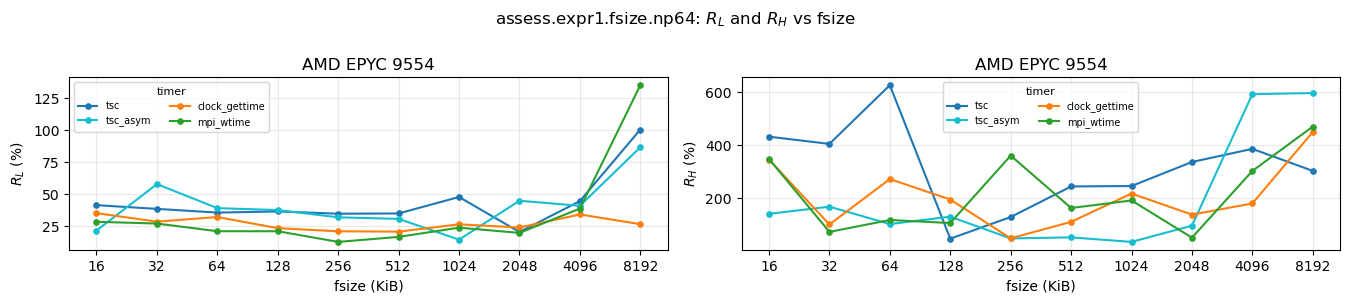

scripts_plot/outputAssessing/manual_expr1_fsize/assess.expr1.fsize.np128_rl_rh_manual_20260521.png


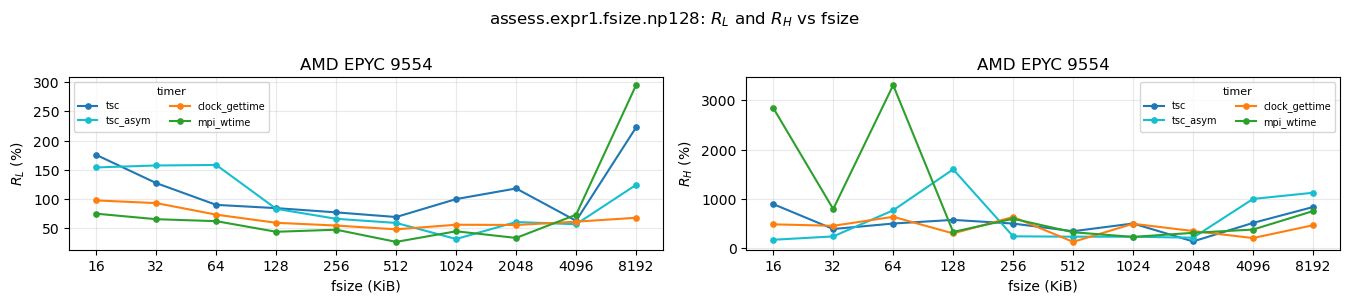

In [ ]:
def plot_rl_rh(df, expr):
    sub = df[df["expr_base"] == expr].copy()
    present_hosts = [h for h in HOSTS if h in set(sub["host"])]
    fig, axes = plt.subplots(len(present_hosts), 2, figsize=(13.6, max(3.0, 2.9 * len(present_hosts))), squeeze=False)
    for row_idx, host in enumerate(present_hosts):
        hdf = sub[sub["host"] == host]
        for col_idx, (metric, ylabel) in enumerate([("r_l_pct", r"$R_L$ (%)"), ("r_h_pct", r"$R_H$ (%)")]):
            ax = axes[row_idx, col_idx]
            for timer in ordered_timers(hdf["timer"]):
                tdf = hdf[hdf["timer"] == timer].sort_values("fsize_kib")
                ax.plot(tdf["fsize_kib"], tdf[metric], marker="o", linewidth=1.5, markersize=3.8,
                        label=timer, color=TIMER_COLORS.get(timer))
            ax.set_title(format_host_name(host))
            ax.set_xlabel("fsize (KiB)")
            ax.set_ylabel(ylabel)
            ax.set_xscale("log", base=2)
            ax.set_xticks(FSIZE_EXPECTED)
            ax.get_xaxis().set_major_formatter(ScalarFormatter())
            ax.grid(True, alpha=0.28)
            if not hdf.empty:
                ax.legend(title="timer", fontsize=7, title_fontsize=8, ncols=2)
    fig.suptitle(f"{expr}: $R_L$ and $R_H$ vs fsize", y=0.995)
    fig.tight_layout()
    out = OUTPUT_DIR / f"{expr}_rl_rh_manual_{DATE}.png"
    fig.savefig(out, dpi=220)
    print(out)
    return fig

for expr in EXPRS:
    if expr in set(df_fig6["expr_base"]):
        display(plot_rl_rh(df_fig6, expr))
        plt.close("all")

scripts_plot/outputAssessing/manual_expr1_fsize/assess.expr1.fsize.np64_wasserstein_manual_20260521.png


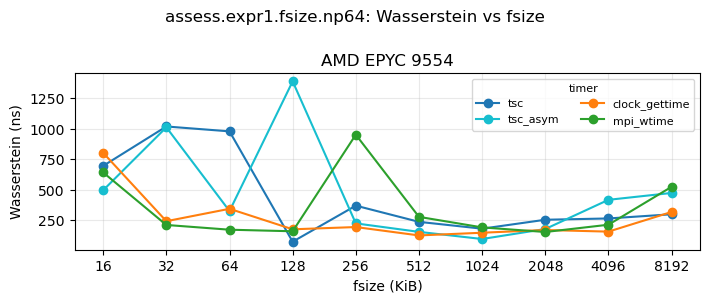

scripts_plot/outputAssessing/manual_expr1_fsize/assess.expr1.fsize.np128_wasserstein_manual_20260521.png


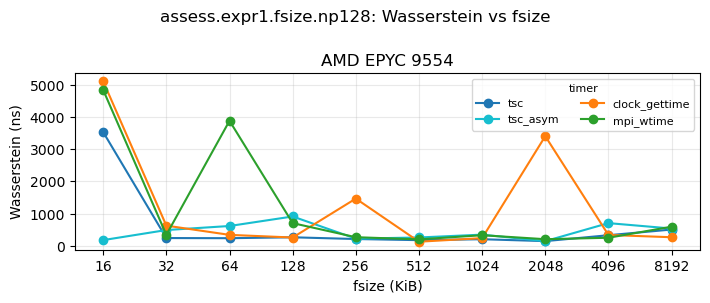

In [ ]:
def plot_wasserstein(df, expr):
    sub = df[df["expr_base"] == expr].copy()
    present_hosts = [h for h in HOSTS if h in set(sub["host"])]
    fig, axes = plt.subplots(len(present_hosts), 1, figsize=(7.2, max(3.0, 2.7 * len(present_hosts))), squeeze=False)
    for ax, host in zip(axes.ravel(), present_hosts):
        hdf = sub[sub["host"] == host]
        for timer in ordered_timers(hdf["timer"]):
            tdf = hdf[hdf["timer"] == timer].sort_values("fsize_kib")
            ax.plot(tdf["fsize_kib"], tdf["w1_ns"], marker="o", linewidth=1.5,
                    label=timer, color=TIMER_COLORS.get(timer))
        ax.set_title(format_host_name(host))
        ax.set_xlabel("fsize (KiB)")
        ax.set_ylabel("Wasserstein (ns)")
        ax.set_xscale("log", base=2)
        ax.set_xticks(FSIZE_EXPECTED)
        ax.get_xaxis().set_major_formatter(ScalarFormatter())
        ax.grid(True, alpha=0.28)
        if not hdf.empty:
            ax.legend(title="timer", fontsize=8, title_fontsize=8, ncols=2)
    fig.suptitle(f"{expr}: Wasserstein vs fsize", y=0.995)
    fig.tight_layout()
    out = OUTPUT_DIR / f"{expr}_wasserstein_manual_{DATE}.png"
    fig.savefig(out, dpi=220)
    print(out)
    return fig

for expr in EXPRS:
    if expr in set(df_fig6["expr_base"]):
        display(plot_wasserstein(df_fig6, expr))
        plt.close("all")